In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("../Data/superstore.csv")

In [13]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [15]:
df.shape

(9994, 13)

In [17]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [21]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [23]:
df.duplicated().sum()

17

In [25]:
df = df.drop_duplicates()

In [27]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [29]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [31]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [33]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

Category
Furniture          741306.3133
Office Supplies    718735.2440
Technology         836154.0330
Name: Sales, dtype: float64


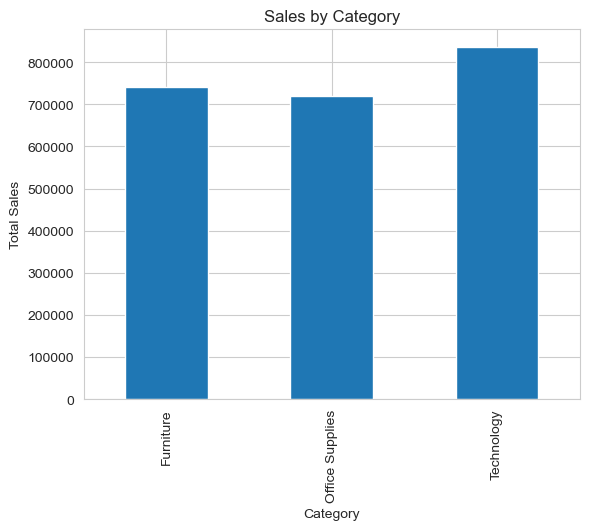

In [35]:
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

Technology category has highest sales among all categories.

In [38]:
category_profit = df.groupby('Category')['Profit'].sum()

print(category_profit)

Category
Furniture           18421.8137
Office Supplies    122364.6608
Technology         145454.9481
Name: Profit, dtype: float64


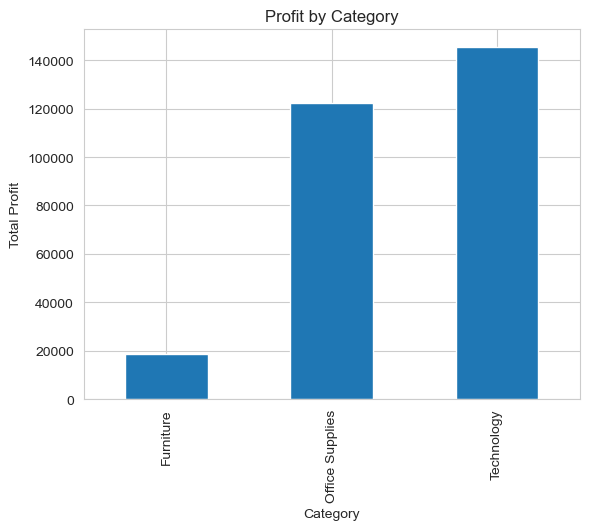

In [40]:
category_profit.plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

In [42]:
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum()

print(subcategory_profit.sort_values())

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Storage        21278.8264
Chairs         26567.1278
Binders        30228.0003
Paper          33944.2395
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


Tables sub-category is loss-making despite contributing to sales.

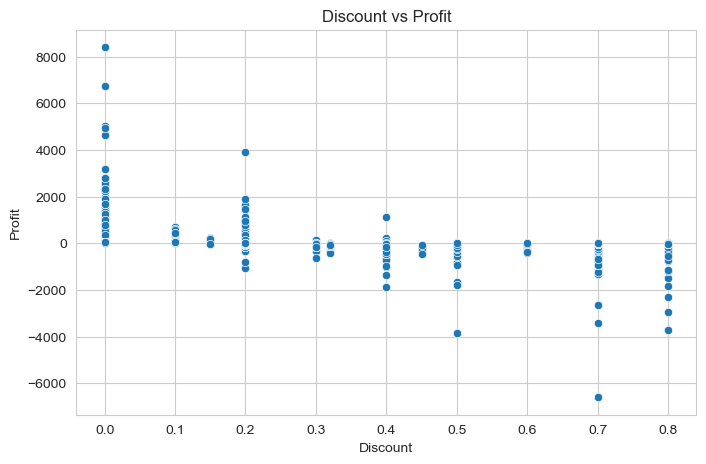

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Discount', y='Profit', data=df)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [47]:
correlation = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

print(correlation)

             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200722 -0.028311  0.479067
Quantity  0.200722  1.000000  0.008678  0.066211
Discount -0.028311  0.008678  1.000000 -0.219662
Profit    0.479067  0.066211 -0.219662  1.000000


Higher discounts are reducing profits.

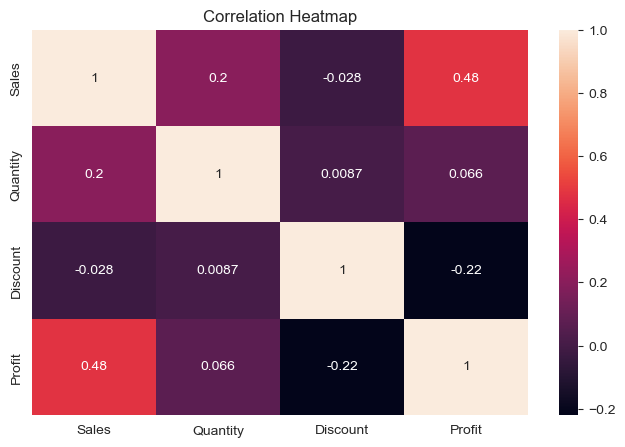

In [50]:
plt.figure(figsize=(8,5))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [52]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

Region
Central    500782.8528
East       678435.1960
South      391721.9050
West       725255.6365
Name: Sales, dtype: float64


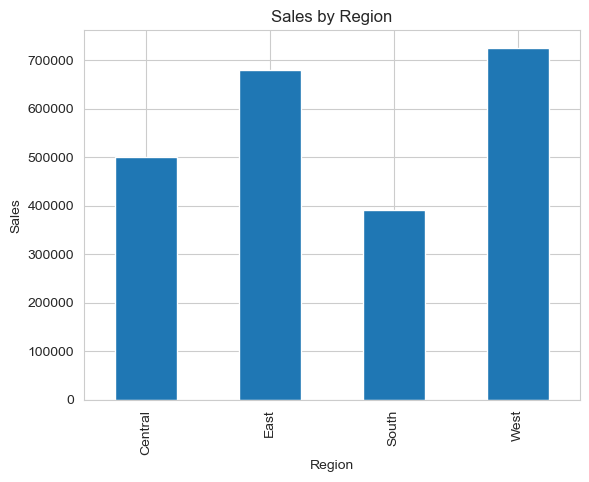

In [54]:
region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [56]:
state_profit = df.groupby('State')['Profit'].sum()

print(state_profit.sort_values().head(10))

State
Texas            -25750.9833
Ohio             -16959.3178
Pennsylvania     -15565.4035
Illinois         -12601.6500
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1194.0993
Name: Profit, dtype: float64


Texas is the most loss-making state.

Profitability issues are concentrated in certain regions.

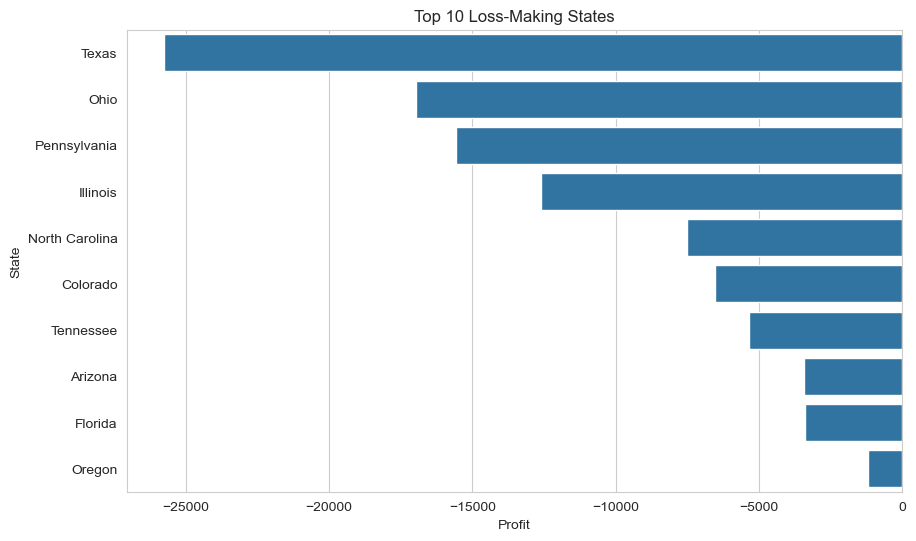

In [60]:
top_loss_states = df.groupby('State')['Profit'].sum().sort_values().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_loss_states.values, y=top_loss_states.index)

plt.title("Top 10 Loss-Making States")
plt.xlabel("Profit")
plt.ylabel("State")

plt.show()

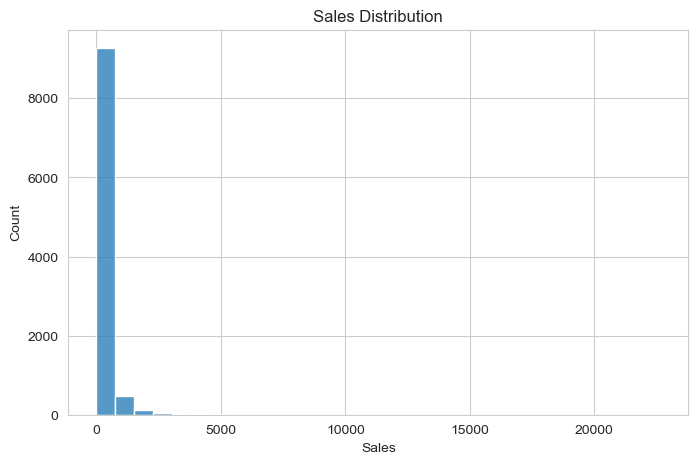

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30)

plt.title("Sales Distribution")

plt.show()

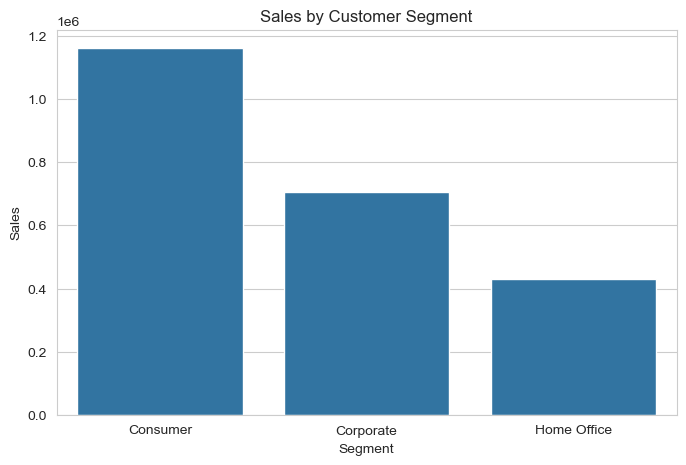

In [64]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=segment_sales.index, y=segment_sales.values)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

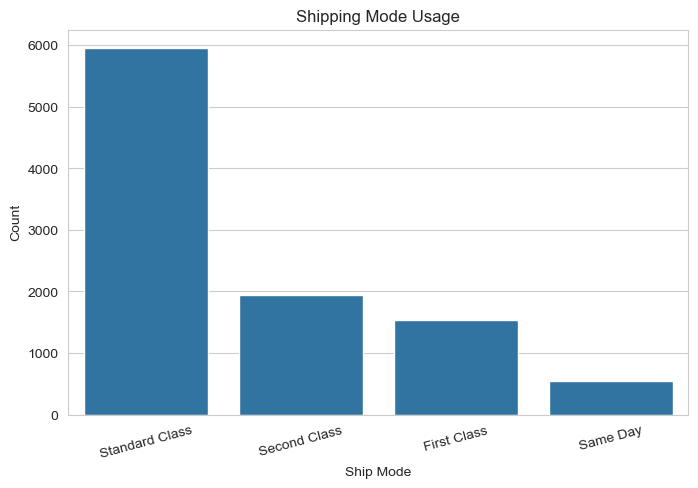

In [66]:
ship_mode = df['Ship Mode'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=ship_mode.index, y=ship_mode.values)

plt.title("Shipping Mode Usage")
plt.xlabel("Ship Mode")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

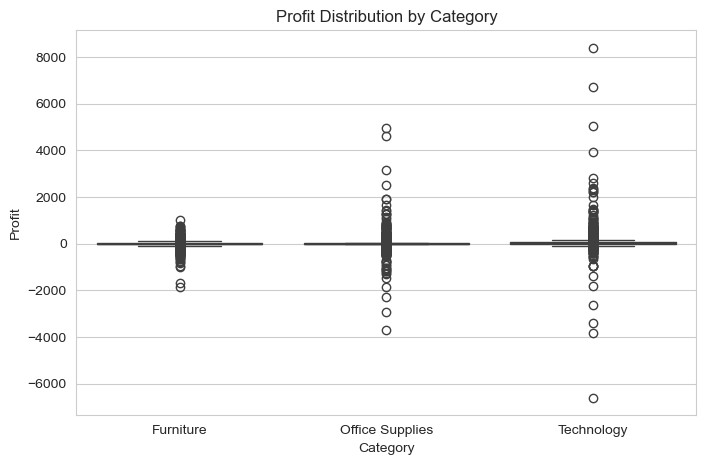

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Category', y='Profit', data=df)

plt.title("Profit Distribution by Category")

plt.show()

In [70]:
df.to_csv("../Data/cleaned_superstore.csv", index=False)